# Maze CNN Classifier

**Silent Cartographer — COSC 4368 AI Spring 2026**

| #   | Label       | Description           |
| --- | ----------- | --------------------- |
| 0   | `path`      | Open traversable cell |
| 1   | `wall`      | Blocked cell          |
| 2   | `death_pit` | Fire emoji            |
| 3   | `confusion` | Yellow smiley pads    |
| 4   | `tp_orange` | Orange teleport pad   |
| 5   | `tp_green`  | Green teleport pad    |
| 6   | `tp_purple` | Purple teleport pad   |
| 7   | `tp_red`    | Red teleport pad      |
| 8   | `start`     | Start cell            |
| 9   | `goal`      | Goal cell             |

**Workflow:** Extract → Label → Dataset → Train → Evaluate → Test with agent


## 0. Imports & Constants


In [66]:
import os, glob, shutil
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
from maze import MazeLoader

CELL_SIZE  = 16
WALL_THICK = 2
INNER_SIZE = CELL_SIZE - 2 * WALL_THICK   # 12
MODEL_PATH = "maze_cnn.pt"
SEED_DIR   = "unique_hazards"
LABEL_DIR  = "labeled_hazards"
MAZE_FILES = ["MAZE_1.png", "MAZE_2.png"]

CLASS_NAMES = [
    "path", "wall", "death_pit", "confusion",
    "tp_orange", "tp_green", "tp_purple", "tp_red",
    "start", "goal"
]
NUM_CLASSES = len(CLASS_NAMES)

LABEL_PATH   = 0
LABEL_WALL   = 1
LABEL_FIRE   = 2
LABEL_CONF   = 3
LABEL_TPO    = 4
LABEL_TPG    = 5
LABEL_TPP    = 6
LABEL_TPR    = 7
LABEL_START  = 8
LABEL_GOAL   = 9

CLASS_COLOURS = [
    (220,220,220),  # path
    ( 30, 30, 30),  # wall
    (255, 60, 60),  # death_pit
    (255,230,  0),  # confusion
    (255,140,  0),  # tp_orange
    ( 40,200, 80),  # tp_green
    (160, 50,255),  # tp_purple
    (200,  0,  0),  # tp_red
    (  0,230,100),  # start
    (  0,210,255),  # goal
]

print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
print(f"Classes: {CLASS_NAMES}")

PyTorch 2.11.0+cpu  |  CUDA: False
Classes: ['path', 'wall', 'death_pit', 'confusion', 'tp_orange', 'tp_green', 'tp_purple', 'tp_red', 'start', 'goal']


## 1. NCC Helper


In [67]:
def ncc(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32) - a.mean()
    b = b.astype(np.float32) - b.mean()
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.sum(a * b) / d) if d > 1e-8 else 0.0


def has_warm_color(bgr):
    """True if patch has warm saturated pixels — likely a hazard, never a plain wall."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    fg  = (hsv[:,:,1] > 60) & (hsv[:,:,2] > 80)
    return int(fg.sum()) >= 8

## 2. Extract Raw Patches → `unique_hazards/`

Extracts all non-white hazard-looking patches from every maze. `force=True` always re-runs.


In [68]:
def extract_raw_patches(maze_files, out_dir=SEED_DIR, dedup_thresh=0.92, force=False):
    existing = glob.glob(f"{out_dir}/*.png")
    if existing and not force:
        print(f"'{out_dir}/' has {len(existing)} images. Pass force=True to re-extract.")
        return

    os.makedirs(out_dir, exist_ok=True)
    saved_patches, total = [], 0

    for maze_path in maze_files:
        if not os.path.exists(maze_path):
            print(f"  {maze_path} not found, skipping"); continue

        loader = MazeLoader(maze_path)
        h, w   = loader.maze_height_cells, loader.maze_width_cells
        name   = os.path.splitext(os.path.basename(maze_path))[0]
        count  = 0

        for r in range(h):
            for c in range(w):
                y0  = r * CELL_SIZE + WALL_THICK
                x0  = c * CELL_SIZE + WALL_THICK
                bgr = loader.bgr[y0:y0+INNER_SIZE, x0:x0+INNER_SIZE]

                # Skip near-white (path/wall)
                hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
                fg  = ~((hsv[:,:,1] < 30) & (hsv[:,:,2] > 200))
                if int(fg.sum()) < 10:
                    continue

                p = cv2.resize(bgr, (INNER_SIZE, INNER_SIZE), interpolation=cv2.INTER_NEAREST)
                if any(ncc(p, ex) >= dedup_thresh for ex in saved_patches):
                    continue

                fname = f"{name}_r{r:02d}_c{c:02d}.png"
                cv2.imwrite(os.path.join(out_dir, fname), p)
                saved_patches.append(p)
                count += 1

        print(f"  {maze_path}: {count} unique patches")
        total += count

    print(f"Total: {total} patches saved to '{out_dir}/'")


extract_raw_patches(MAZE_FILES, force=True)

  MAZE_1.png: 26 unique patches
  MAZE_2.png: 6 unique patches
Total: 32 patches saved to 'unique_hazards/'


## 3. Manual Labeling Tool

Each patch is shown at 8× zoom. Click the correct label. Progress auto-saves to `labeled_hazards/`.
Re-running resumes where you left off.


In [69]:
os.makedirs(LABEL_DIR, exist_ok=True)

already_labeled = set()
for p in glob.glob(f"{LABEL_DIR}/*.png"):
    parts = os.path.basename(p).split("_", 2)
    if len(parts) == 3:
        already_labeled.add(parts[2])

all_images   = [p for p in sorted(glob.glob(f"{SEED_DIR}/*.png"))
                if os.path.basename(p) not in already_labeled]
idx_state    = {"i": 0}
label_counts = {l: len(glob.glob(f"{LABEL_DIR}/{l}_*.png")) for l in CLASS_NAMES}
print(f"{len(all_images)} images to label  |  {len(already_labeled)} already done")


def save_labeled(fpath, label):
    n     = label_counts[label]
    fname = f"{label}_{n:03d}_{os.path.basename(fpath)}"
    shutil.copy(fpath, os.path.join(LABEL_DIR, fname))
    label_counts[label] += 1


img_widget   = widgets.Image(format="png", width=160, height=160)
progress_bar = widgets.IntProgress(value=0, min=0, max=max(len(all_images), 1),
                                   description="Progress:",
                                   layout=widgets.Layout(width="420px"))
status_lbl = widgets.Label(value="")
info_lbl   = widgets.Label(value="")


def show_current():
    i = idx_state["i"]
    progress_bar.value = i
    if i >= len(all_images):
        img_widget.value = b""
        info_lbl.value   = ""
        status_lbl.value = f"✓ All {i} images labeled!"
        return
    fpath = all_images[i]
    bgr   = cv2.imread(fpath, cv2.IMREAD_COLOR)
    big   = cv2.resize(bgr, (INNER_SIZE*8, INNER_SIZE*8), interpolation=cv2.INTER_NEAREST)
    _, buf = cv2.imencode(".png", big)
    img_widget.value = buf.tobytes()
    info_lbl.value   = f"{i+1}/{len(all_images)}  —  {os.path.basename(fpath)}"


def make_btn(label, colour):
    b = widgets.Button(description=label,
                       style={"button_color": colour},
                       layout=widgets.Layout(width="110px", height="36px"))
    def on_click(_):
        if idx_state["i"] < len(all_images):
            save_labeled(all_images[idx_state["i"]], label)
            status_lbl.value = f"✓  saved as '{label}'"
        idx_state["i"] += 1
        show_current()
    b.on_click(on_click)
    return b


btn_skip = widgets.Button(description="Skip",
                          style={"button_color": "#aaaaaa"},
                          layout=widgets.Layout(width="80px", height="36px"))
btn_back = widgets.Button(description="← Back",
                          layout=widgets.Layout(width="80px", height="36px"))

def on_skip(_): idx_state["i"] += 1; status_lbl.value = "— skipped"; show_current()
def on_back(_):
    if idx_state["i"] > 0: idx_state["i"] -= 1
    show_current()

btn_skip.on_click(on_skip)
btn_back.on_click(on_back)

row_hazard = widgets.HBox([
    make_btn("death_pit", "#ff6b6b"),
    make_btn("confusion", "#ffd93d"),
    make_btn("tp_orange", "#ffb347"),
    make_btn("tp_green",  "#6bcb77"),
    make_btn("tp_purple", "#c77dff"),
    make_btn("tp_red",    "#cc0000"),
])
row_other = widgets.HBox([
    make_btn("path",  "#dddddd"),
    make_btn("wall",  "#888888"),
    make_btn("start", "#00e676"),
    make_btn("goal",  "#00e5ff"),
    btn_skip, btn_back,
])

display(widgets.VBox([
    progress_bar, info_lbl, img_widget, status_lbl,
    widgets.Label("── Hazards ──────────────────────────────────────"),
    row_hazard,
    widgets.Label("── Other ─────────────────────────────────────────"),
    row_other,
]))
show_current()

31 images to label  |  40 already done


## 4. Review Labeled Seeds


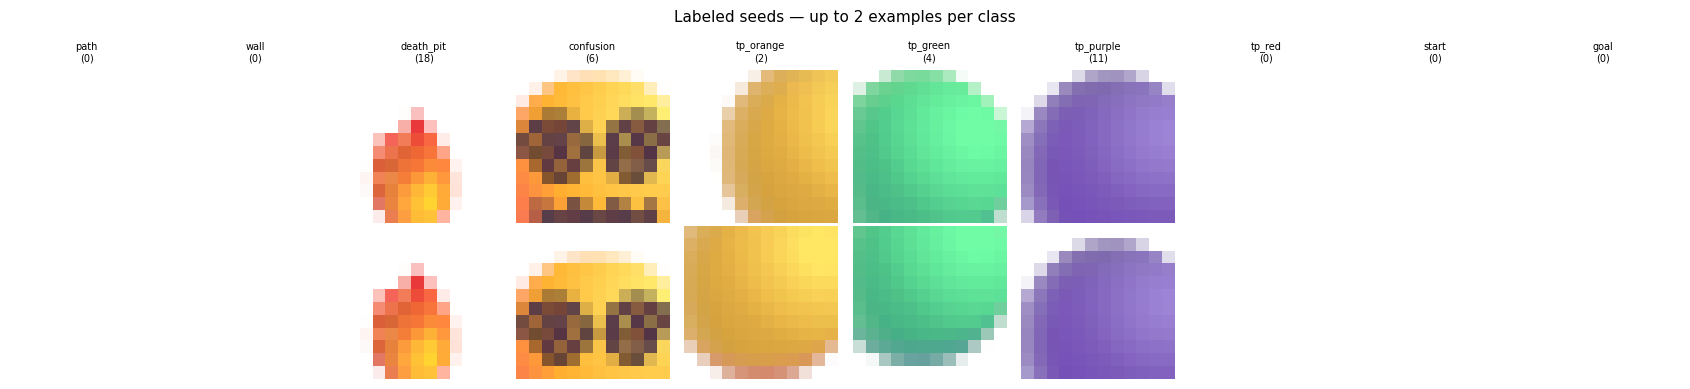

In [70]:
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.7, 4))
fig.suptitle("Labeled seeds — up to 2 examples per class", fontsize=11)

for ci, name in enumerate(CLASS_NAMES):
    paths = sorted(glob.glob(f"{LABEL_DIR}/{name}_*.png"))
    for row in range(2):
        ax = axes[row, ci]
        if row < len(paths):
            img = cv2.cvtColor(cv2.imread(paths[row]), cv2.COLOR_BGR2RGB)
            ax.imshow(cv2.resize(img, (48,48), interpolation=cv2.INTER_NEAREST))
        else:
            ax.imshow(np.ones((48,48,3)))
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{name}\n({len(paths)})", fontsize=7)

plt.tight_layout(); plt.show()

## 5. Build Dataset via NCC + Boundary-Pixel Wall Detection


In [71]:
HAZARD_LABELS = ["death_pit", "confusion", "tp_orange", "tp_green",
                 "tp_purple", "tp_red"]
NCC_THRESHOLD = 0.45   # lower threshold catches more fire cells


def load_seeds(label_dir=LABEL_DIR):
    seeds = {}
    for name in CLASS_NAMES:
        paths  = sorted(glob.glob(f"{label_dir}/{name}_*.png"))
        loaded = [cv2.resize(cv2.imread(p, cv2.IMREAD_COLOR),
                             (INNER_SIZE, INNER_SIZE), interpolation=cv2.INTER_NEAREST)
                  for p in paths if cv2.imread(p) is not None]
        if loaded:
            seeds[name] = loaded
            print(f"  {name:<12}: {len(loaded)} seed(s)")
    return seeds


def is_path_cell(loader, r, c):
    """Check boundary pixels — matches environment.py adjacency logic."""
    ma    = loader.maze_array
    hm, wm = ma.shape[0]-1, ma.shape[1]-1
    hc, wc = loader.maze_height_cells, loader.maze_width_cells
    mid   = CELL_SIZE // 2
    checks = []
    if r+1 < hc: checks.append((min((r+1)*CELL_SIZE, hm), min(c*CELL_SIZE+mid, wm)))
    if r   > 0:  checks.append((min(r*CELL_SIZE,     hm), min(c*CELL_SIZE+mid, wm)))
    if c+1 < wc: checks.append((min(r*CELL_SIZE+mid, hm), min((c+1)*CELL_SIZE, wm)))
    if c   > 0:  checks.append((min(r*CELL_SIZE+mid, hm), min(c*CELL_SIZE,     wm)))
    return any(bool(ma[py, px]) for py, px in checks)


def best_hazard_match(patch_bgr, seeds):
    best_label, best_score = None, -1.0
    for label in HAZARD_LABELS:
        if label not in seeds: continue
        for seed in seeds[label]:
            s = ncc(patch_bgr, seed)
            if s > best_score:
                best_score, best_label = s, label
    return (best_label if best_score >= NCC_THRESHOLD else None), best_score


def build_dataset(maze_path, seeds):
    loader = MazeLoader(maze_path)
    h, w   = loader.maze_height_cells, loader.maze_width_cells
    sc     = loader.pixel_to_cell(*loader.start_pos)
    gc     = loader.pixel_to_cell(*loader.goal_pos)

    patches, labels = [], []
    for r in range(h):
        for c in range(w):
            y0  = r * CELL_SIZE + WALL_THICK
            x0  = c * CELL_SIZE + WALL_THICK
            bgr = loader.bgr[y0:y0+INNER_SIZE, x0:x0+INNER_SIZE]
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            t   = np.transpose(rgb, (2, 0, 1))

            pos = (r, c)
            if pos == sc:
                label = LABEL_START
            elif pos == gc:
                label = LABEL_GOAL
            else:
                hazard, _ = best_hazard_match(bgr, seeds)
                if hazard is not None:
                    label = CLASS_NAMES.index(hazard)
                elif has_warm_color(bgr):
                    # Coloured but unmatched — safer to call path than wall
                    label = LABEL_PATH
                else:
                    label = LABEL_PATH if is_path_cell(loader, r, c) else LABEL_WALL

            patches.append(t)
            labels.append(label)

    return np.stack(patches).astype(np.float32), np.array(labels, dtype=np.int64)


print("Loading labeled seeds...")
seeds = load_seeds(LABEL_DIR)

if not seeds:
    print("\n⚠ No seeds found — run the labeling tool first (Cell 3).")
else:
    print("\nBuilding dataset...")
    all_patches, all_labels = [], []
    for mf in MAZE_FILES:
        if not os.path.exists(mf): continue
        print(f"  {mf}")
        p, l = build_dataset(mf, seeds)
        all_patches.append(p); all_labels.append(l)
        unique, counts = np.unique(l, return_counts=True)
        for u, cnt in zip(unique, counts):
            print(f"    {CLASS_NAMES[u]:<12}: {cnt}")

    patches = np.concatenate(all_patches)
    labels  = np.concatenate(all_labels)
    print(f"\nTotal: {len(labels)} cells")

Loading labeled seeds...
  death_pit   : 18 seed(s)
  confusion   : 6 seed(s)
  tp_orange   : 2 seed(s)
  tp_green    : 4 seed(s)
  tp_purple   : 11 seed(s)

Building dataset...
  MAZE_1.png
    path        : 4029
    death_pit   : 54
    confusion   : 4
    tp_orange   : 3
    tp_green    : 2
    tp_purple   : 2
    start       : 1
    goal        : 1
  MAZE_2.png
    path        : 3965
    death_pit   : 129
    start       : 1
    goal        : 1

Total: 8192 cells


## 6. Dataset Samples per Class


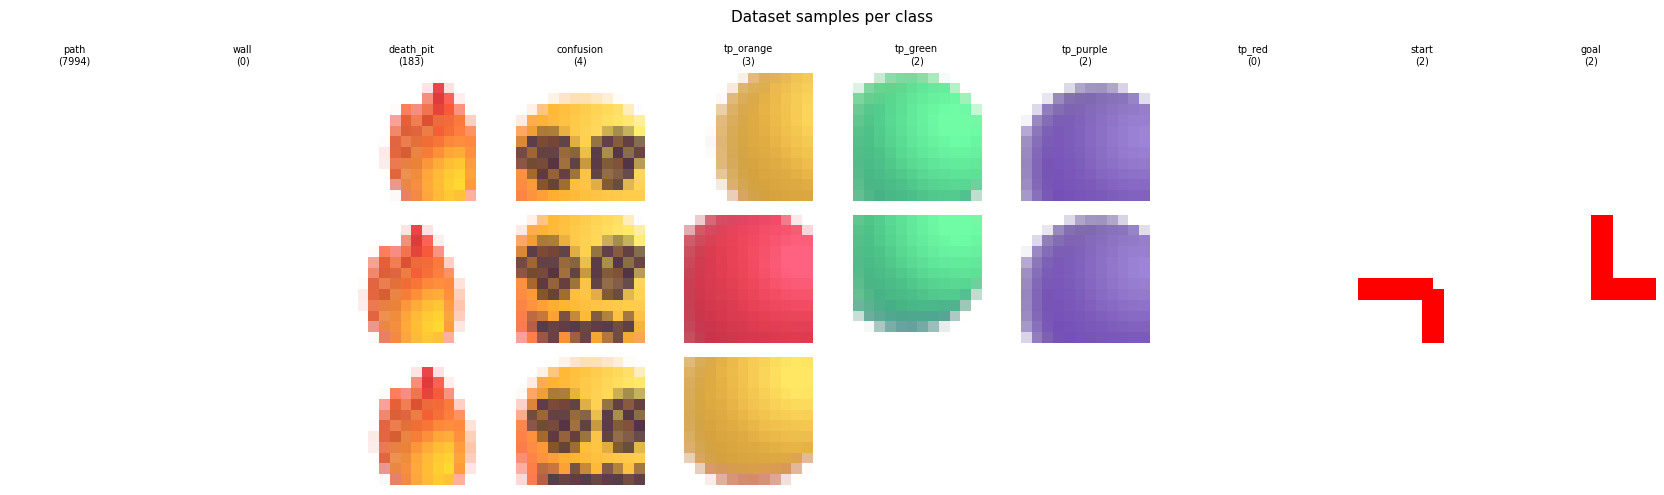

In [72]:
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(NUM_CLASSES * 1.7, 5))
fig.suptitle("Dataset samples per class", fontsize=11)

for ci, name in enumerate(CLASS_NAMES):
    mask = np.where(labels == ci)[0]
    for row in range(3):
        ax = axes[row, ci]
        if row < len(mask):
            img = np.transpose(patches[mask[row]], (1,2,0))
            ax.imshow(img, interpolation="nearest")
        else:
            ax.imshow(np.ones((INNER_SIZE,INNER_SIZE,3)))
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{name}\n({len(mask)})", fontsize=7)

plt.tight_layout(); plt.show()

## 7. PyTorch Dataset


In [73]:
class MazeCellDataset(Dataset):
    def __init__(self, patches, labels, augment=False):
        self.patches = torch.from_numpy(patches)
        self.labels  = torch.from_numpy(labels)
        self.augment = augment

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        x = self.patches[idx].clone()
        if self.augment:
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[2])
            if torch.rand(1) > 0.5: x = torch.flip(x, dims=[1])
            x = (x + (torch.rand(1) - 0.5) * 0.08).clamp(0, 1)
        return x, self.labels[idx]


BATCH = 128
n     = len(labels)
idx   = np.random.permutation(n)
split = int(n * 0.9)
tr_idx, va_idx = idx[:split], idx[split:]

tr_ds = MazeCellDataset(patches[tr_idx], labels[tr_idx], augment=True)
va_ds = MazeCellDataset(patches[va_idx], labels[va_idx])
tr_dl = DataLoader(tr_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
va_dl = DataLoader(va_ds, batch_size=BATCH, shuffle=False, num_workers=0)
print(f"Train: {len(tr_ds)}  Val: {len(va_ds)}")

Train: 7372  Val: 820


## 8. CNN Architecture


In [74]:
class MazeCellCNN(nn.Module):
    """(B,3,12,12) → (B,NUM_CLASSES). Two conv blocks + FC."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*3*3, 128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x): return self.head(self.features(x))

    def predict(self, patch_bgr):
        rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        t   = torch.from_numpy(np.transpose(rgb, (2,0,1))).unsqueeze(0)
        with torch.no_grad():
            probs = F.softmax(self(t), dim=1)
            conf, cls = probs.max(dim=1)
        return int(cls.item()), float(conf.item())

    def save(self, path=MODEL_PATH):
        torch.save(self.state_dict(), path); print(f"Saved → {path}")

    @classmethod
    def load(cls, path=MODEL_PATH):
        m = cls()
        m.load_state_dict(torch.load(path, map_location="cpu"))
        m.eval(); return m


model = MazeCellCNN()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 141,098


## 9. Training


In [75]:
EPOCHS = 30
LR     = 1e-3

counts  = np.bincount(labels, minlength=NUM_CLASSES).astype(np.float32)
counts  = np.where(counts == 0, 1, counts)
weights = torch.tensor(1.0 / counts)
weights = weights / weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {"tr_loss": [], "tr_acc": [], "va_acc": []}
best_va   = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for x, y in tr_dl:
        optimizer.zero_grad()
        out  = model(x); loss = criterion(out, y)
        loss.backward(); optimizer.step()
        tr_loss    += loss.item() * len(y)
        tr_correct += (out.argmax(1) == y).sum().item()
        tr_total   += len(y)
    scheduler.step()

    model.eval()
    va_correct = va_total = 0
    with torch.no_grad():
        for x, y in va_dl:
            out = model(x)
            va_correct += (out.argmax(1) == y).sum().item()
            va_total   += len(y)

    tr_acc = tr_correct / tr_total * 100
    va_acc = va_correct / va_total * 100
    history["tr_loss"].append(tr_loss / tr_total)
    history["tr_acc"].append(tr_acc)
    history["va_acc"].append(va_acc)

    tag = ""
    if va_acc > best_va:
        best_va = va_acc; model.save(MODEL_PATH); tag = " ★"

    print(f"Epoch {epoch:3d}/{EPOCHS}  loss={tr_loss/tr_total:.4f}  "
          f"train={tr_acc:.1f}%  val={va_acc:.1f}%{tag}")

print(f"\nBest val accuracy: {best_va:.2f}%")

Saved → maze_cnn.pt
Epoch   1/30  loss=1.2437  train=91.4%  val=96.6% ★
Saved → maze_cnn.pt
Epoch   2/30  loss=0.9094  train=96.1%  val=96.7% ★
Epoch   3/30  loss=0.9421  train=96.8%  val=2.4%
Epoch   4/30  loss=0.8429  train=96.7%  val=96.7%
Epoch   5/30  loss=0.9253  train=96.7%  val=96.7%
Epoch   6/30  loss=0.6360  train=96.8%  val=96.7%
Epoch   7/30  loss=0.7326  train=96.7%  val=96.7%
Epoch   8/30  loss=0.8305  train=96.8%  val=96.6%
Epoch   9/30  loss=0.6419  train=96.8%  val=96.6%
Epoch  10/30  loss=0.6226  train=96.8%  val=2.4%
Epoch  11/30  loss=0.6584  train=96.9%  val=96.7%
Epoch  12/30  loss=0.6330  train=96.9%  val=96.7%
Epoch  13/30  loss=0.6782  train=96.9%  val=96.7%
Epoch  14/30  loss=0.5381  train=96.9%  val=96.7%
Epoch  15/30  loss=0.5567  train=96.9%  val=96.7%
Epoch  16/30  loss=0.5446  train=96.9%  val=96.7%
Epoch  17/30  loss=0.5886  train=96.9%  val=96.7%
Epoch  18/30  loss=0.5071  train=96.9%  val=96.7%
Epoch  19/30  loss=0.4448  train=96.9%  val=96.7%
Epoch  2

## 10. Training Curves


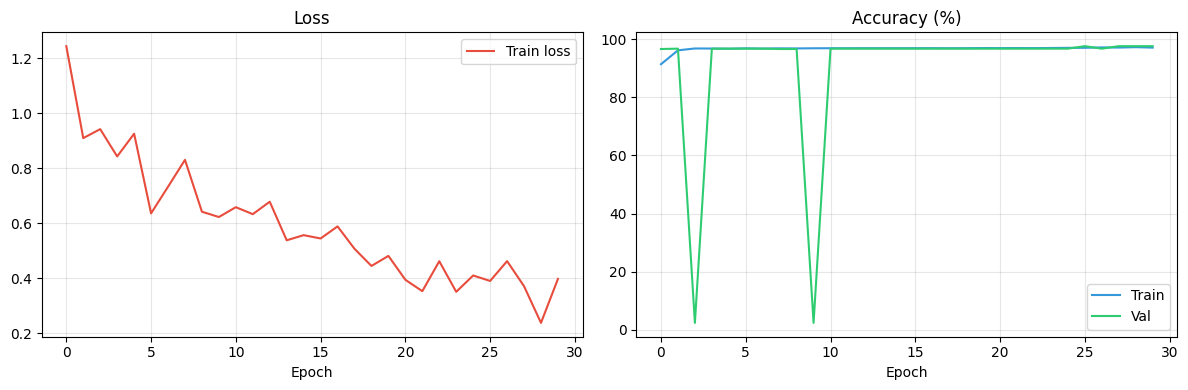

In [76]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["tr_loss"], color="#e74c3c", label="Train loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history["tr_acc"], color="#3498db", label="Train")
ax2.plot(history["va_acc"], color="#2ecc71", label="Val")
ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Per-class Accuracy


In [77]:
model = MazeCellCNN.load(MODEL_PATH)

all_preds, all_true = [], []
with torch.no_grad():
    for x, y in DataLoader(MazeCellDataset(patches, labels), batch_size=256):
        all_preds.append(model(x).argmax(1).numpy())
        all_true.append(y.numpy())

preds = np.concatenate(all_preds)
true  = np.concatenate(all_true)
print(f"Overall accuracy: {(preds == true).mean()*100:.2f}%\n")
print(f"{'Class':<12} {'Acc':>7}  {'Samples':>8}")
print("-" * 32)
for i, name in enumerate(CLASS_NAMES):
    mask = true == i
    if not mask.any(): continue
    print(f"{name:<12} {(preds[mask]==i).mean()*100:>6.1f}%  {mask.sum():>8d}")

Overall accuracy: 97.64%

Class            Acc   Samples
--------------------------------
path           97.7%      7994
death_pit     100.0%       183
confusion     100.0%         4
tp_orange       0.0%         3
tp_green      100.0%         2
tp_purple     100.0%         2
start           0.0%         2
goal            0.0%         2


## 12. Visualise CNN Predictions


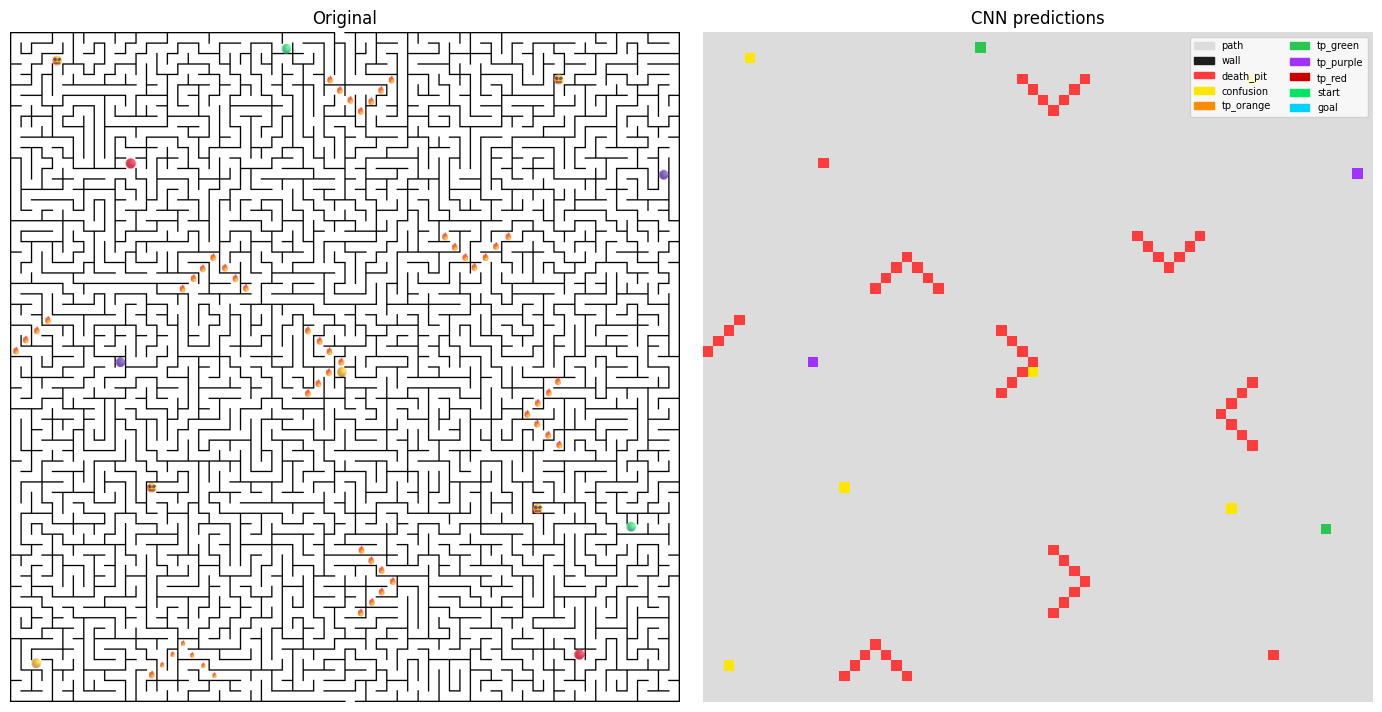

In [78]:
def predict_full_maze(maze_path, model):
    loader = MazeLoader(maze_path)
    h, w   = loader.maze_height_cells, loader.maze_width_cells
    grid   = np.zeros((h, w, 3), dtype=np.uint8)
    model.eval()
    for r in range(h):
        for c in range(w):
            y0  = r * CELL_SIZE + WALL_THICK
            x0  = c * CELL_SIZE + WALL_THICK
            bgr = loader.bgr[y0:y0+INNER_SIZE, x0:x0+INNER_SIZE]
            cls, _ = model.predict(bgr)
            grid[r, c] = CLASS_COLOURS[cls]
    return grid


EVAL_MAZE = next((m for m in MAZE_FILES if os.path.exists(m)), None)
if EVAL_MAZE:
    grid = predict_full_maze(EVAL_MAZE, model)
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(Image.open(EVAL_MAZE)); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(grid, interpolation="nearest")
    axes[1].set_title("CNN predictions"); axes[1].axis("off")
    legend_p = [mpatches.Patch(color=np.array(c)/255, label=n)
                for c, n in zip(CLASS_COLOURS, CLASS_NAMES)]
    axes[1].legend(handles=legend_p, loc="upper right", fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

Loading environment from MAZE_1.png...
searching 64×64 cells for hazards
Found 67 hazardous cells


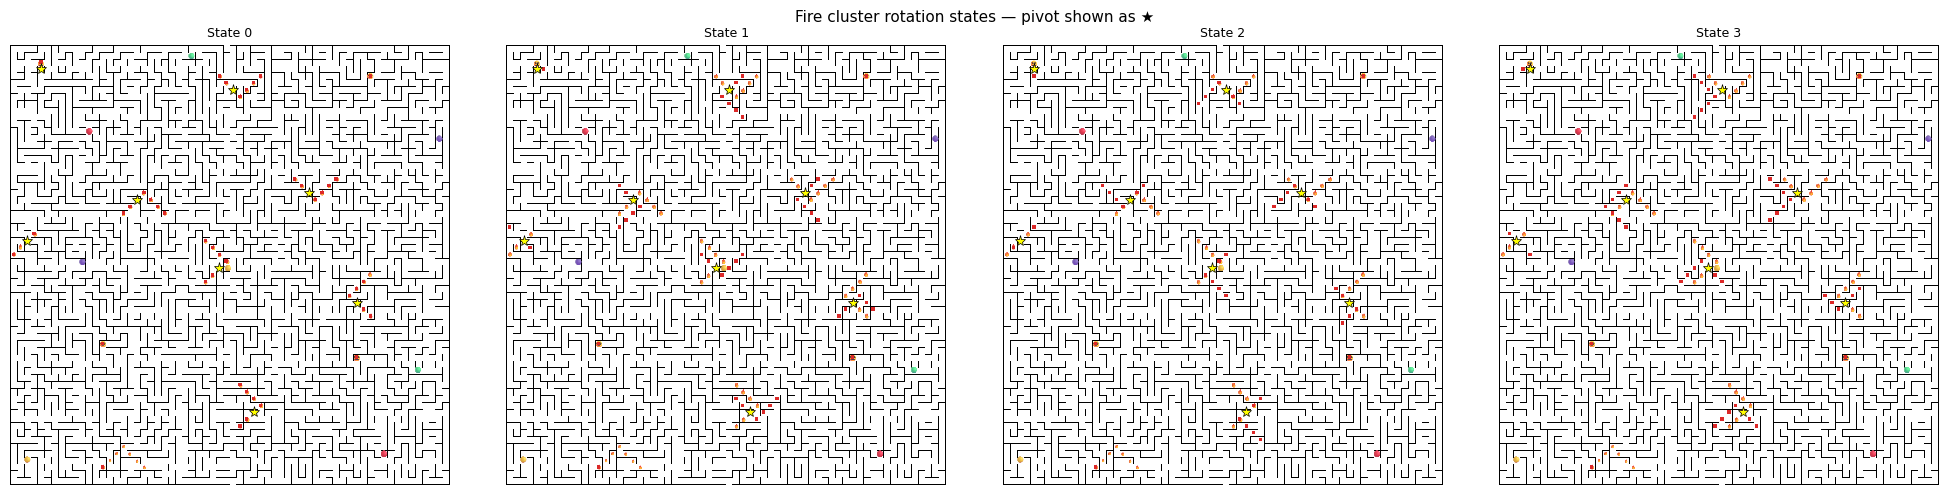


Cluster summary (12 clusters):
  Cluster  0:  2 cells  pivot=(3,4)  bbox=rows[2-3] cols[4-4]
  Cluster  1:  7 cells  pivot=(22,18)  bbox=rows[21-24] cols[16-22]
  Cluster  2:  7 cells  pivot=(32,30)  bbox=rows[28-34] cols[28-31]
  Cluster  3:  3 cells  pivot=(28,2)  bbox=rows[27-30] cols[0-3]
  Cluster  4:  7 cells  pivot=(53,35)  bbox=rows[49-55] cols[33-36]
  Cluster  5:  7 cells  pivot=(21,43)  bbox=rows[19-22] cols[41-47]
  Cluster  6:  7 cells  pivot=(6,32)  bbox=rows[4-7] cols[30-36]
  Cluster  7:  6 cells  pivot=(37,50)  bbox=rows[34-39] cols[49-52]
  Cluster  8:  1 cells  pivot=(61,13)  bbox=rows[61-61] cols[13-13]
  Cluster  9:  1 cells  pivot=(43,13)  bbox=rows[43-43] cols[13-13]
  Cluster 10:  1 cells  pivot=(45,50)  bbox=rows[45-45] cols[50-50]
  Cluster 11:  1 cells  pivot=(4,52)  bbox=rows[4-4] cols[52-52]


In [79]:
# ── Cell 13: Verify fire cluster pivots ──────────────────────────────────────
from environment import MazeEnvironment

print(f"Loading environment from {EVAL_MAZE}...")
env = MazeEnvironment(EVAL_MAZE)

# Draw all 4 rotation states side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Fire cluster rotation states — pivot shown as ★", fontsize=11)

maze_base = np.array(Image.open(EVAL_MAZE).convert("RGB"))

for rot_idx in range(4):
    ax  = axes[rot_idx]
    img = maze_base.copy()

    fire_state = env._fire_rotation_states[rot_idx]

    # Draw fire cells (red)
    for r, c in fire_state:
        y0 = r * 16 + 4;  y1 = y0 + 8
        x0 = c * 16 + 4;  x1 = x0 + 8
        img[y0:y1, x0:x1] = [220, 40, 40]

    ax.imshow(img, interpolation="nearest")
    ax.set_title(f"State {rot_idx}", fontsize=9)
    ax.axis("off")

    # Mark pivot cells (bright yellow dot)
    for cluster in env.initial_fire_clusters:
        if len(cluster) <= 1:
            continue
        rows = [r for r, _ in cluster]; cols = [c for _, c in cluster]
        cr = sum(rows) / len(rows);     cc  = sum(cols) / len(cols)
        pr, pc = min(cluster, key=lambda cell: (cell[0]-cr)**2 + (cell[1]-cc)**2)
        py = pr * 16 + 8;  px = pc * 16 + 8
        ax.plot(px, py, "*", color="yellow", markersize=8, markeredgecolor="black",
                markeredgewidth=0.5, zorder=5)

plt.tight_layout(); plt.show()

print(f"\nCluster summary ({len(env.initial_fire_clusters)} clusters):")
for i, cluster in enumerate(env.initial_fire_clusters):
    rows = [r for r, _ in cluster]; cols = [c for _, c in cluster]
    cr = sum(rows)/len(rows); cc = sum(cols)/len(cols)
    pr, pc = min(cluster, key=lambda cell: (cell[0]-cr)**2 + (cell[1]-cc)**2)
    print(f"  Cluster {i:2d}: {len(cluster):2d} cells  pivot=({pr},{pc})  "
          f"bbox=rows[{min(rows)}-{max(rows)}] cols[{min(cols)}-{max(cols)}]")

## 13. CnnMazeLoader — Drop-in for `environment.py`

Swap this into `environment.py` to use the CNN for hazard detection:

```python
from maze_cnn import CnnMazeLoader
# in MazeEnvironment.__init__:
self.loader = CnnMazeLoader(maze_image_path)
```

> **Note on `tp_red`:** The environment currently has no `teleport_red` group in `MazeLoader`.
> After swapping in `CnnMazeLoader`, add this to `MazeEnvironment.__init__` to handle red teleports:
>
> ```python
> self.teleport_red = set(map(tuple, self.loader.teleport_red))
> # then add to teleport_map loop and all_hazard_cells
> ```


In [80]:
class CnnMazeLoader(MazeLoader):
    """
    Drop-in for MazeLoader. Uses CNN; falls back to color classifier on low confidence.
    Adds teleport_red as a new hazard list.
    """
    _CLS_MAP = {
        LABEL_FIRE:  "death_pit",
        LABEL_CONF:  "confusion",
        LABEL_TPO:   "teleport_orange",
        LABEL_TPG:   "teleport_green",
        LABEL_TPP:   "teleport_purple",
        LABEL_TPR:   "teleport_red",
    }
    CONF_THRESHOLD = 0.70

    def __init__(self, image_path, model_path=MODEL_PATH, **kwargs):
        super().__init__(image_path, **kwargs)
        self.teleport_red = []   # new hazard list
        if os.path.exists(model_path):
            self._cnn = MazeCellCNN.load(model_path)
            print(f"[CnnMazeLoader] CNN loaded from {model_path}")
        else:
            self._cnn = None
            print(f"[CnnMazeLoader] no model found — color classifier only")

    def classify_cell_template(self, r, c):
        if self._cnn is not None:
            patch = self.cell_interior_bgr(r, c)
            cls, conf = self._cnn.predict(patch)
            if cls in self._CLS_MAP and conf >= self.CONF_THRESHOLD:
                return self._CLS_MAP[cls]
        return super().classify_cell_template(r, c)

    def detect_hazards(self):
        summary = super().detect_hazards()
        # Re-scan for tp_red (not in parent's detect_hazards)
        for r in range(self.maze_height_cells):
            for c in range(self.maze_width_cells):
                if self._cnn is not None:
                    patch = self.cell_interior_bgr(r, c)
                    cls, conf = self._cnn.predict(patch)
                    if cls == LABEL_TPR and conf >= self.CONF_THRESHOLD:
                        self.teleport_red.append((r, c))
        summary["teleport_red"] = len(self.teleport_red)
        return summary


if EVAL_MAZE:
    cnn_loader = CnnMazeLoader(EVAL_MAZE)
    summary    = cnn_loader.detect_hazards()
    print("\nHazard summary:")
    for k, v in summary.items():
        print(f"  {k:<20}: {v}")

[CnnMazeLoader] CNN loaded from maze_cnn.pt
searching 64×64 cells for hazards
Found 67 hazardous cells

Hazard summary:
  death_pits          : 56
  confusion           : 4
  teleport_purple     : 2
  teleport_orange     : 3
  teleport_green      : 2
  start_pos           : (1025, 521)
  goal_pos            : (0, 505)
  teleport_red        : 0


## 14. Test the Map with Your Agent

This cell runs a single episode of your trained neuroevolution agent on the maze,
using `CnnMazeLoader` for detection, and visualises the path it takes.


searching 64×64 cells for hazards
Found 67 hazardous cells
Start: (63, 32)  Goal: (0, 31)
Death pits: 50  Confusion: 2  Teleports: 15

  ── Episode 1/1  start=(63, 32)  goal=(0, 31) ──
  t00002 →  pos=(63, 33)  dist= 65  WALL×1
  t00015 ↓  pos=(63, 33)  dist= 65  WALL×1
  t00016 ↓  pos=(63, 33)  dist= 65  WALL×1
  t00017 ↓  pos=(63, 33)  dist= 65  WALL×1
  t00019 ←  pos=(62, 33)  dist= 64  WALL×1
  t00020 ←  pos=(62, 33)  dist= 64  WALL×1
  t00021 ←  pos=(62, 33)  dist= 64  WALL×1
  t00022 ↑  pos=(62, 33)  dist= 64  WALL×1
  t00023 ↑  pos=(62, 33)  dist= 64  WALL×1
  t00024 ↑  pos=(62, 33)  dist= 64  WALL×1
  t00025 →  pos=(62, 33)  dist= 64  WALL×1
  t00026 ↑  pos=(62, 33)  dist= 64  WALL×1
  t00027 ↑  pos=(62, 33)  dist= 64  WALL×1
  t00030 ↑  pos=(63, 32)  dist= 64  WALL×1
  t00031 ↑  pos=(63, 32)  dist= 64  WALL×1
  t00032 ↑  pos=(63, 32)  dist= 64  WALL×1
  t00044 ↑  pos=(63, 31)  dist= 63  WALL×1
  t00045 ↑  pos=(63, 31)  dist= 63  WALL×1
  t00046 ↑  pos=(63, 31)  dist= 63  WALL×

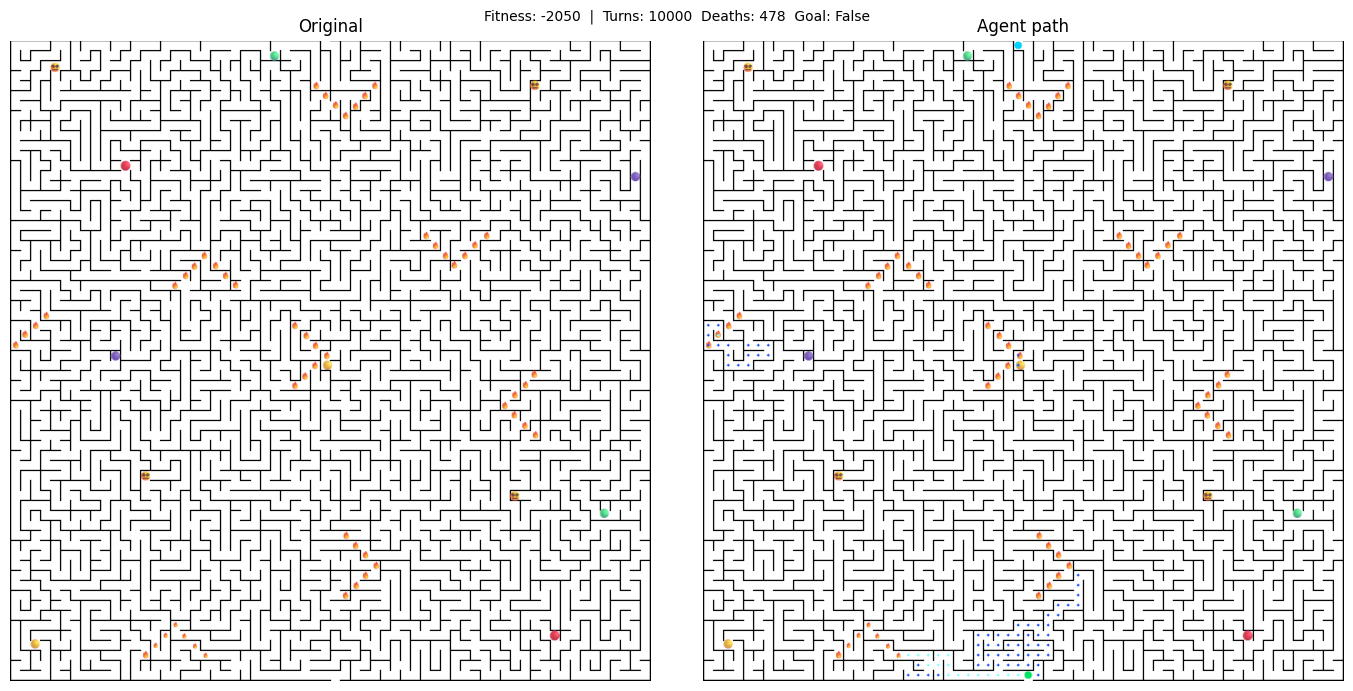

In [81]:
import sys
sys.path.insert(0, ".")  # make sure local files are importable

from environment import MazeEnvironment, Action
from maze_agent  import NeuralController, EvolutionaryAgent, configure, evaluate_fitness

AGENT_WEIGHTS = "best_weights.npy"   # saved by live_viz.py training
TEST_MAZE     = EVAL_MAZE
MAX_TURNS     = 10_000

if not os.path.exists(AGENT_WEIGHTS):
    print(f"⚠ No weights found at '{AGENT_WEIGHTS}' — run training first.")
else:
    # ── 1. Build environment with CNN loader ─────────────────────────────────
    # Monkey-patch MazeLoader so MazeEnvironment picks up CnnMazeLoader
    import maze as _maze_module
    _original_loader = _maze_module.MazeLoader
    _maze_module.MazeLoader = CnnMazeLoader

    env = MazeEnvironment(TEST_MAZE)
    configure(env.start_cell, env.goal_cell)

    _maze_module.MazeLoader = _original_loader   # restore

    print(f"Start: {env.start_cell}  Goal: {env.goal_cell}")
    print(f"Death pits: {len(env.death_pits)}  "
          f"Confusion: {len(env.confusion_pads)}  "
          f"Teleports: {len(env.teleport_map)}")

    # ── 2. Load best weights and run one episode ──────────────────────────────
    ctrl = NeuralController()
    ctrl.load(AGENT_WEIGHTS)

    from maze_agent import GOAL_CELL, START_CELL
    fitness, agent = evaluate_fitness(
        ctrl, env,
        goal_cell=GOAL_CELL, start_cell=START_CELL,
        episodes=1, max_turns=MAX_TURNS,
        epsilon=0.0, verbose=True,
    )
    stats = env.get_episode_stats()
    print(f"\nFitness: {fitness:+.0f}")
    print(f"Goal reached: {stats['goal_reached']}")
    print(f"Turns: {stats['turns_taken']}  Deaths: {stats['deaths']}  "
          f"Explored: {stats['cells_explored']} cells")

    # ── 3. Visualise path ─────────────────────────────────────────────────────
    maze_img = np.array(Image.open(TEST_MAZE).convert("RGB"))
    overlay  = maze_img.copy()

    path = agent.memory.path
    n    = max(1, len(path) - 1)
    for i, (r, c) in enumerate(path):
        t  = i / n
        py = r * CELL_SIZE + CELL_SIZE // 2
        px = c * CELL_SIZE + CELL_SIZE // 2
        colour = (int(30+100*t), int(80+175*t), 255)
        cv2.circle(overlay, (px, py), 2, colour, -1)

    # Mark start and goal
    sr, sc_ = env.start_cell
    gr, gc_ = env.goal_cell
    cv2.circle(overlay, (sc_*CELL_SIZE+8, sr*CELL_SIZE+8), 6, (0,230,100), -1)
    cv2.circle(overlay, (gc_*CELL_SIZE+8, gr*CELL_SIZE+8), 6, (0,210,255), -1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(maze_img);  axes[0].set_title("Original");       axes[0].axis("off")
    axes[1].imshow(overlay);   axes[1].set_title("Agent path");      axes[1].axis("off")
    plt.suptitle(f"Fitness: {fitness:+.0f}  |  Turns: {stats['turns_taken']}  "
                 f"Deaths: {stats['deaths']}  Goal: {stats['goal_reached']}",
                 fontsize=10)
    plt.tight_layout(); plt.show()